In [ ]:
import pandas as pd
import numpy as np
import regex as re
import matplotlib.pyplot as plt

In [ ]:
# party affiliation of U.S. presidents (in pres_df)  <- done
# number of executive orders signed by U.S. presidents  <- done
# executive_orders = pd.read_csv("executive_orders.csv")
# Highest military rank held by U.S. presidents (in pres_df) <- done
# Previous roles and professions of U.S. presidents (in pres_df) <- done
# Number of children of U.S. presidents (in pres_df) <- done
# Length of presidential terms (in pres_df)
# Length of inagural addresses of U.S. presidents

In [ ]:
df = pd.read_csv("presidents.csv")

# so i can see the full df
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

df.head()

,No.,Name,Birthplace,Birthday,Life,Height,Children,Religion,Higher Education,Occupation,Military Service,Term,Party,Vice President,Previous Office,Economy,Foreign Affairs,Military Activity,Other Events,Legacy
0,1,George Washington,"Pope's Creek, VA",22-Feb,1732-1799,1.88,0,Episcopalian,NaN,"Plantation Owner, Soldier",Commander-in-Chief of the Continental Army in the Revolutionary War,1789-1797,"None, Federalist",John Adams,Commander-in-Chief,"[' Hamilton established BUS', '1792 Coinage Act', '1792 New York Stock Exchange organized.', '1791 Bank Act: banking...","['1793 Neutrality in the France-Britain conflict', '1795 Jay Treaty with Britain. British forces withdrew', ""1795 Pi...",['1794 Whiskey Rebellion'],"['1791 Bill of Rights', '1792 Post Office founded.', '1792, 1796 Kentucky & Tennessee joined the Union']","He is universally regarded as one of the greatest figures in U.S. history. “First in war, first in peace, and first ..."
1,2,John Adams,"Braintree, MA",30-Oct,1735-1826,1.70,5,Unitarian,Harvard,"Lawyer, Farmer",none,1797-1801,Federalist,Thomas Jefferson,1st Vice President of USA,['1798 Progressive land value tax of up to 1% of the value of a property'],['1797 the XYZ Affair: a bribe of French agents leaked'],['1798–1800 The Quasi war. Undeclared naval war with France'],"['1798 Alien & Sedition Act to silence critics; unpopular', '1800 Capital relocated to Washington DC', '1801 Nominat...",One of the most experienced men ever to become President. Played a major role in the movement for independence. By t...
2,3,Thomas Jefferson,"Goochland County, VA",13-Apr,1743-1826,1.89,6,unaffiliated Christian,College of William and Mary,"Inventor,Lawyer, Architect",Colonel of Virginia militia (without real military service),1801-1809,Democratic-Republican,"Aaron Burr, George Clinton",2nd Vice President of USA,"['1807 Embargo Act forbidding foreign trade in war', ' Canceled Whiskey Tax.', '1809 Non-Intercourse Act repealing ...",['1805 Peace Treaty with Tripoli. Piracy stopped.'],['1801-05 Naval operation against Tripoli and Barbary pirates'],"['1803 The Louisiana purchase', '1804 12th Amendment changed Presidential election', '1804-06 Authorized Louis & Cla...","Probably the most intelligent man ever to occupy the White House. Of broad interests and activity, he exerted an im..."
3,4,James Madison,"Port Conway, VA",16-Mar,1751-1836,1.63,0,Episcopalian,Princeton,"Plantation Owner, Lawyer",Colonel of Virginia militia (without real military service),1809-1817,Democratic-Republican,"George Clinton, Elbridge Gerry",Secretary of State,"[' The first U.S. protective tariff was imposed', ' Second Bank of the United States established']",['1814 The Treaty of Ghent ends the War of 1812'],"['1811 Tippecanoe battle (Harrison vs. Chief Tecumseh)', '1812-15 War of 1812 with the British. Disastrous.', '1815 ...","['1811 Cumberland Road construction starts (first National Road)', '1817 Veto on Bonus Bill for funding States imp...","His leadership in the War of 1812 was particularly inept. But the young nation emerged united and strong, and Madis..."
4,5,James Monroe,"Monroe Hall, VA",28-Apr,1758-1831,1.83,2,Episcopalian,College of William and Mary,"Plantation Owner, Lawyer",Major of the Continental Army,1817-1825,Democratic-Republican,Daniel Tompkins,Secretary of War,['1819 Panic of 1819 (too much land speculation)'],"['1823 Monroe Doctrine', '1818 49th parallel set as the border with Canada.', '1818 Russo-American Treaty: Russia ou...",['1817 1st Seminole war against Seminole Indians in Florida. Jackson in action.'],"['1819 Florida ceded to US', ""1820 Missouri Compromise Slavery forbidden abv 36° 30'"", '1820 In the election he rece...",His presidency contributed to national defense and security. The Monroe Doctrine became a landmark in American forei...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No.                47 non-null     int64  
 1   Name               47 non-null     object 
 2   Birthplace         47 non-null     object 
 3   Birthday           47 non-null     object 
 4   Life               47 non-null     object 
 5   Height             47 non-null     float64
 6   Children           47 non-null     int64  
 7   Religion           47 non-null     object 
 8   Higher Education   37 non-null     object 
 9   Occupation         47 non-null     object 
 10  Military Service   47 non-null     object 
 11  Term               47 non-null     object 
 12  Party              47 non-null     object 
 13  Vice President     47 non-null     object 
 14  Previous Office    47 non-null     object 
 15  Economy            46 non-null     object 
 16  Foreign Affairs    46 non-nu

In [ ]:
df.describe()

,No.,Height,Children
count,47.000000,47.000000,47.000000
mean,24.000000,1.801277,3.148936
std,13.711309,0.069489,2.063963
min,1.000000,1.630000,0.000000
25%,12.500000,1.750000,2.000000
50%,24.000000,1.800000,3.000000
75%,35.500000,1.850000,5.000000
max,47.000000,1.930000,8.000000


In [ ]:
# adding a bool column for college+
df["has_higher_education"] = (
    df["Higher Education"].notna()
    & (df["Higher Education"].astype(str).str.strip() != "")
)

In [ ]:
# to make groups based on what their previous office held was
def group_previous_office(text):
    text = str(text).lower().strip()
    if "vice president" in text:
        return "Vice President"
    if "governor" in text:
        return "Governor"
    if "senator" in text or "congressman" in text:
        return "Legislative"
    if "secretary" in text or "minister" in text:
        return "Cabinet"
    if "chief justice" in text or "judge" in text:
        return "Judicial"
    if "general" in text or "commander" in text or "army" in text:
        return "Military Leadership"
    if "president of usa" in text:
        return "Former President"
    if text == "none":
        return "No Major Prior Office Listed"
    return "Other"

df["previous_office_group"] = df["Previous Office"].apply(group_previous_office)

In [ ]:
# to get starting and ending year for era definitions
def parse_term(term):
    years = re.findall(r"\d{4}", str(term))
    if len(years) == 0:
      return None, None
    if len(years) == 1:
        return int(years[0]), int(years[0])
    return int(years[0]), int(years[1])

df[["term_start", "term_end"]] = df["Term"].apply(parse_term).apply(pd.Series)

In [ ]:
# 1789-now

In [ ]:
# trying to define presidential eras based on war

# Founding generation: 1789–1816 # revolution/founding
# Civil War generation: 1817–1876 # union and civil war
# Between Civil War and World War I: 1877–1916 # industrial expansion
# World Wars generation: 1917–1945 # world wars
# Cold War generation: 1946–1991 # cold war command
# War on Terror: 1992–present # modern day

def assign_era(term_start):
    if pd.isna(term_start):
        return None
    elif 1789 <= term_start <= 1860:
        return "Founding Generation"
    elif 1861 <= term_start <= 1876:
        return "Civil War"
    elif 1877 <= term_start <= 1916:
        return "Industrial Expansion"
    elif 1917 <= term_start <= 1945:
        return "World Wars"
    elif 1946 <= term_start <= 1991:
        return "Cold War"
    elif term_start >= 1992:
        return "Modern Day"
    else:
        return ""

df["era"] = df["term_start"].apply(assign_era)


In [ ]:
df['era'].value_counts()

,count
era,
Founding Generation,15
Industrial Expansion,10
Cold War,8
Modern Day,6
World Wars,5
Civil War,3


In [ ]:
df["has_military_service"] = ~df["Military Service"].str.contains(
    "none", case=False, na=False
)

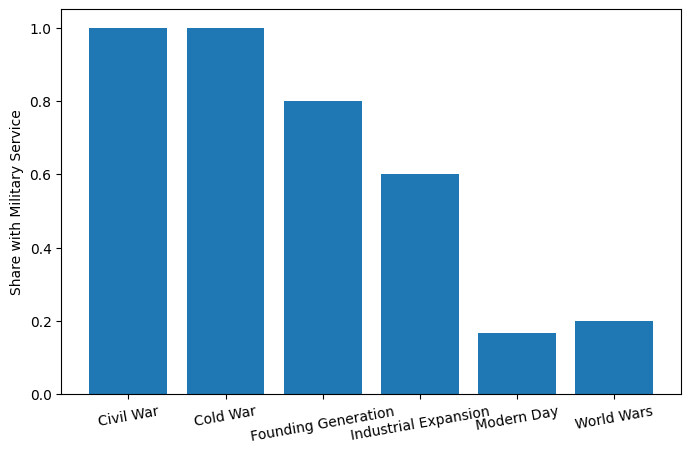

In [ ]:
plt.figure(figsize=(8, 5))
military_share = df.groupby("era", observed=False)["has_military_service"].mean()
plt.bar(military_share.index.astype(str), military_share.values)
plt.ylabel("Share with Military Service")
plt.xticks(rotation=10)
plt.show()

In [ ]:
# trying to now order the eras correctly

era_order = [
    "Founding Generation",
    "Civil War",
    "Industrial Expansion",
    "World Wars",
    "Cold War",
    "Modern Day"
]

df["era"] = pd.Categorical(df["era"], categories=era_order, ordered=True)


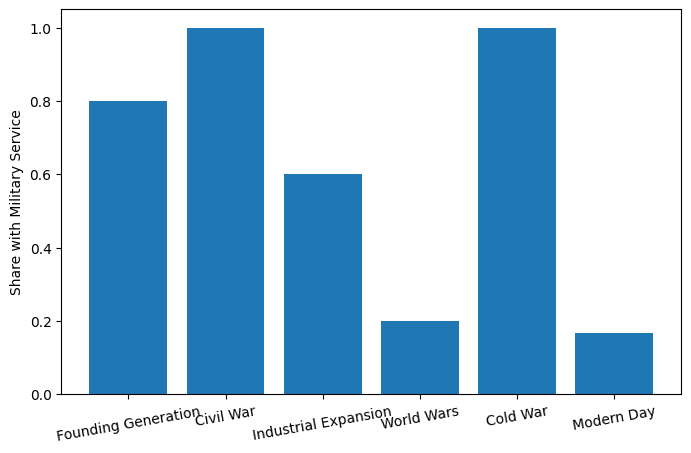

In [ ]:
plt.figure(figsize=(8, 5))
military_share = df.groupby("era", observed=False)["has_military_service"].mean()
plt.bar(military_share.index.astype(str), military_share.values)
plt.ylabel("Share with Military Service")
plt.xticks(rotation=10)
plt.show()

In [ ]:
military_share

,has_military_service
era,
Founding Generation,0.800000
Civil War,1.000000
Industrial Expansion,0.600000
World Wars,0.200000
Cold War,1.000000
Modern Day,0.166667


In [ ]:
# now instead of just yes/no military, trying to assign more of an order of how high up
def military_level(text):
    text = str(text).lower().strip()

    if text == "none" or text == "" or text == "nan":
        return "No service"

    if "commander-in-chief" in text or "general of the army" in text:
        return "Top command"

    if "major general" in text or "brigadier general" in text or "brigadier gen" in text:
        return "Senior leadership"

    if "colonel" in text or "major " in text or text.startswith("major") or "commander -" in text or "quartermaster general" in text:
        return "Mid-level officer"

    if "captain" in text or "lieutenant" in text or "lt. commander" in text or "private" in text:
        return "Lower-level service"

    return "Other / unclear"

df["military_level"] = df["Military Service"].apply(military_level)

In [ ]:
order = [
    "No service",
    "Lower-level service",
    "Mid-level officer",
    "Senior leadership",
    "Top command"
]

df["military_level"] = pd.Categorical(df["military_level"], categories=order, ordered=True)

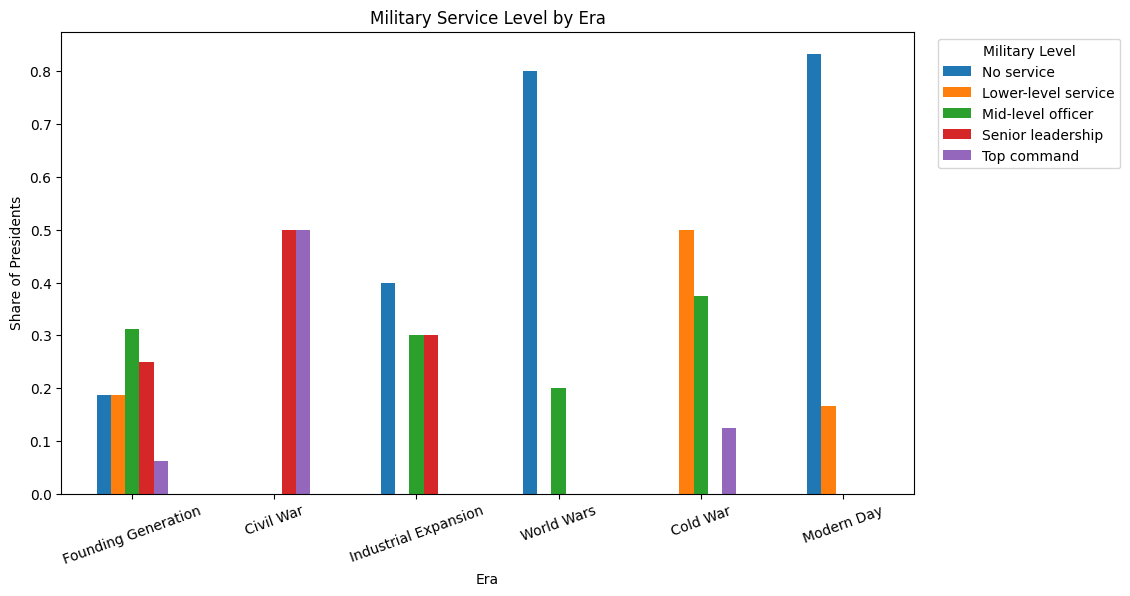

In [ ]:
mil_by_era = pd.crosstab(df["era"], df["military_level"])
mil_by_era_pct = mil_by_era.div(mil_by_era.sum(axis=1), axis=0)

mil_by_era_pct[order].plot(kind="bar", figsize=(11, 6))
plt.title("Military Service Level by Era")
plt.xlabel("Era")
plt.ylabel("Share of Presidents")
plt.xticks(rotation=20)
plt.legend(title="Military Level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

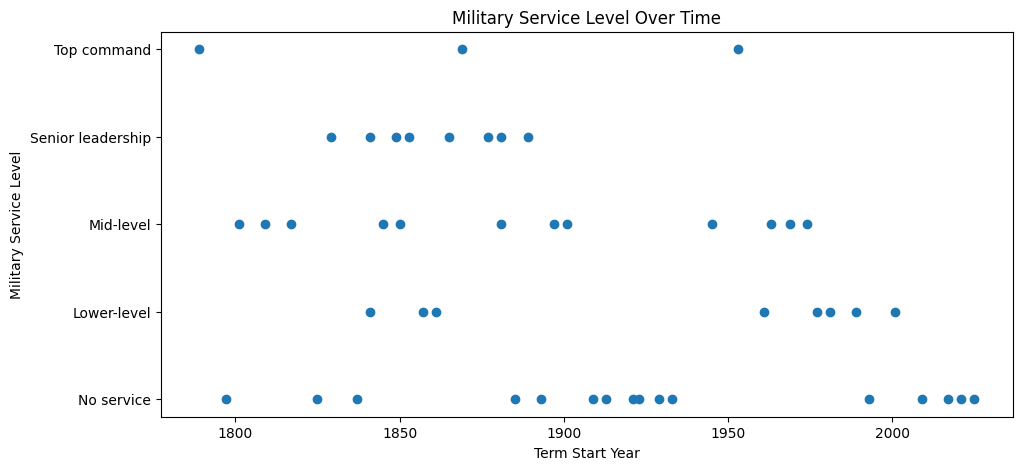

In [ ]:
level_to_num = {
    "No service": 0,
    "Lower-level service": 1,
    "Mid-level officer": 2,
    "Senior leadership": 3,
    "Top command": 4
}

df["military_level_num"] = df["military_level"].map(level_to_num)

plt.figure(figsize=(11, 5))
plt.scatter(df["term_start"], df["military_level_num"])
plt.yticks(
    [0, 1, 2, 3, 4],
    ["No service", "Lower-level", "Mid-level", "Senior leadership", "Top command"]
)
plt.title("Military Service Level Over Time")
plt.xlabel("Term Start Year")
plt.ylabel("Military Service Level")
plt.show()

In [ ]:
df.head()

,No.,Name,Birthplace,Birthday,Life,Height,Children,Religion,Higher Education,Occupation,Military Service,Term,Party,Vice President,Previous Office,Economy,Foreign Affairs,Military Activity,Other Events,Legacy,has_higher_education,previous_office_group,term_start,term_end,era,has_military_service,military_level,military_level_num
0,1,George Washington,"Pope's Creek, VA",22-Feb,1732-1799,1.88,0,Episcopalian,NaN,"Plantation Owner, Soldier",Commander-in-Chief of the Continental Army in the Revolutionary War,1789-1797,"None, Federalist",John Adams,Commander-in-Chief,"[' Hamilton established BUS', '1792 Coinage Act', '1792 New York Stock Exchange organized.', '1791 Bank Act: banking...","['1793 Neutrality in the France-Britain conflict', '1795 Jay Treaty with Britain. British forces withdrew', ""1795 Pi...",['1794 Whiskey Rebellion'],"['1791 Bill of Rights', '1792 Post Office founded.', '1792, 1796 Kentucky & Tennessee joined the Union']","He is universally regarded as one of the greatest figures in U.S. history. “First in war, first in peace, and first ...",False,Military Leadership,1789,1797,Founding Generation,True,Top command,4
1,2,John Adams,"Braintree, MA",30-Oct,1735-1826,1.70,5,Unitarian,Harvard,"Lawyer, Farmer",none,1797-1801,Federalist,Thomas Jefferson,1st Vice President of USA,['1798 Progressive land value tax of up to 1% of the value of a property'],['1797 the XYZ Affair: a bribe of French agents leaked'],['1798–1800 The Quasi war. Undeclared naval war with France'],"['1798 Alien & Sedition Act to silence critics; unpopular', '1800 Capital relocated to Washington DC', '1801 Nominat...",One of the most experienced men ever to become President. Played a major role in the movement for independence. By t...,True,Vice President,1797,1801,Founding Generation,False,No service,0
2,3,Thomas Jefferson,"Goochland County, VA",13-Apr,1743-1826,1.89,6,unaffiliated Christian,College of William and Mary,"Inventor,Lawyer, Architect",Colonel of Virginia militia (without real military service),1801-1809,Democratic-Republican,"Aaron Burr, George Clinton",2nd Vice President of USA,"['1807 Embargo Act forbidding foreign trade in war', ' Canceled Whiskey Tax.', '1809 Non-Intercourse Act repealing ...",['1805 Peace Treaty with Tripoli. Piracy stopped.'],['1801-05 Naval operation against Tripoli and Barbary pirates'],"['1803 The Louisiana purchase', '1804 12th Amendment changed Presidential election', '1804-06 Authorized Louis & Cla...","Probably the most intelligent man ever to occupy the White House. Of broad interests and activity, he exerted an im...",True,Vice President,1801,1809,Founding Generation,True,Mid-level officer,2
3,4,James Madison,"Port Conway, VA",16-Mar,1751-1836,1.63,0,Episcopalian,Princeton,"Plantation Owner, Lawyer",Colonel of Virginia militia (without real military service),1809-1817,Democratic-Republican,"George Clinton, Elbridge Gerry",Secretary of State,"[' The first U.S. protective tariff was imposed', ' Second Bank of the United States established']",['1814 The Treaty of Ghent ends the War of 1812'],"['1811 Tippecanoe battle (Harrison vs. Chief Tecumseh)', '1812-15 War of 1812 with the British. Disastrous.', '1815 ...","['1811 Cumberland Road construction starts (first National Road)', '1817 Veto on Bonus Bill for funding States imp...","His leadership in the War of 1812 was particularly inept. But the young nation emerged united and strong, and Madis...",True,Cabinet,1809,1817,Founding Generation,True,Mid-level officer,2
4,5,James Monroe,"Monroe Hall, VA",28-Apr,1758-1831,1.83,2,Episcopalian,College of William and Mary,"Plantation Owner, Lawyer",Major of the Continental Army,1817-1825,Democratic-Republican,Daniel Tompkins,Secretary of War,['1819 Panic of 1819 (too much land speculation)'],"['1823 Monroe Doctrine', '1818 49th parallel set as the border with Canada.', '1818 Russo-American Treaty: Russia ou...",['1817 1st Seminole war against Seminole Indians in Florida. Jackson in action.'],"['1819 Florida ceded to US',

In [ ]:
# since all presidents had multiple jobs, this table is **one row per job**

occ_long = (
    df[["Name", "Occupation", "term_start", "Party", "era"]]
    .assign(occupation_split=lambda x: x["Occupation"].fillna("").str.split(r"\s*,\s*"))
    .explode("occupation_split")
    .rename(columns={"occupation_split": "occupation_individual"})
)

occ_long["occupation_individual"] = occ_long["occupation_individual"].str.strip()
occ_long = occ_long[occ_long["occupation_individual"] != ""].copy()

occ_long.head(20)

,Name,Occupation,term_start,Party,era,occupation_individual
0,George Washington,"Plantation Owner, Soldier",1789,"None, Federalist",Founding Generation,Plantation Owner
0,George Washington,"Plantation Owner, Soldier",1789,"None, Federalist",Founding Generation,Soldier
1,John Adams,"Lawyer, Farmer",1797,Federalist,Founding Generation,Lawyer
1,John Adams,"Lawyer, Farmer",1797,Federalist,Founding Generation,Farmer
2,Thomas Jefferson,"Inventor,Lawyer, Architect",1801,Democratic-Republican,Founding Generation,Inventor
2,Thomas Jefferson,"Inventor,Lawyer, Architect",1801,Democratic-Republican,Founding Generation,Lawyer
2,Thomas Jefferson,"Inventor,Lawyer, Architect",1801,Democratic-Republican,Founding Generation,Architect
3,James Madison,"Plantation Owner, Lawyer",1809,Democratic-Republican,Founding Generation,Plantation Owner
3,James Madison,"Plantation Owner, Lawyer",1809,Democratic-Republican,Founding Generation,Lawyer
4,James Monroe,"Plantation Owner, Lawyer",1817,Democratic-Republican,Founding Generation,Plantation Owner


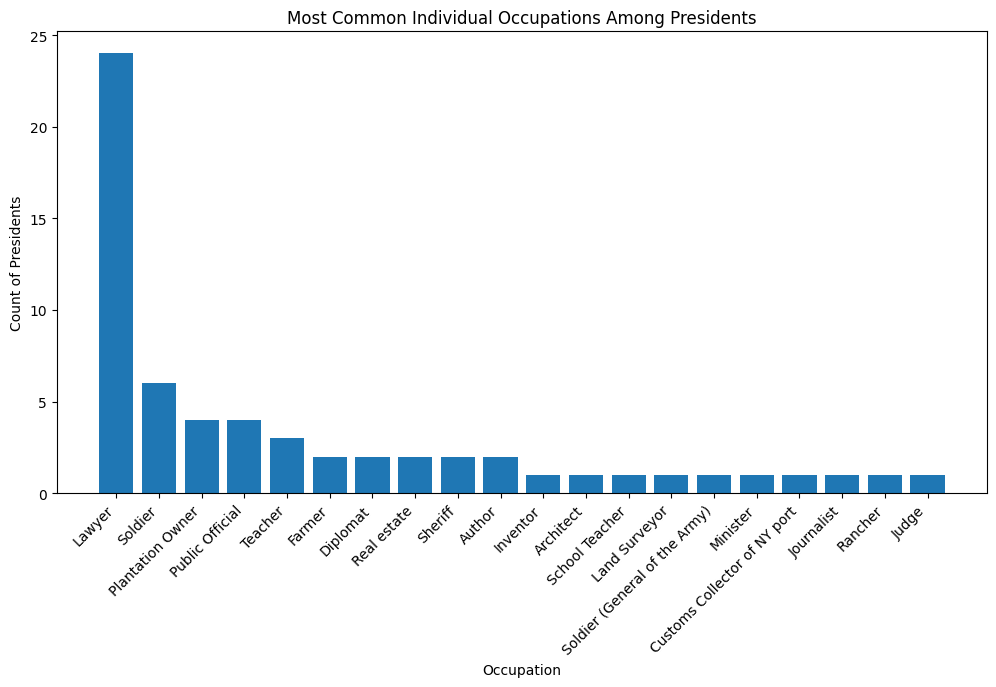

,count
occupation_individual,
Lawyer,24
Soldier,6
Plantation Owner,4
Public Official,4
Teacher,3
Farmer,2
Diplomat,2
Real estate,2
Sheriff,2


In [ ]:
occ_counts = occ_long["occupation_individual"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(occ_counts.head(20).index, occ_counts.head(20).values)
plt.title("Most Common Individual Occupations Among Presidents")
plt.xlabel("Occupation")
plt.ylabel("Count of Presidents")
plt.xticks(rotation=45, ha="right")
plt.show()

occ_counts

In [ ]:
# broad grouping dictionary
occupation_group_map = {
    # law / legal
    "Lawyer": "Law / Legal",
    "Judge": "Law / Legal",
    "Dean of Law School": "Law / Legal",
    "Law Lecturer": "Law / Legal",
    "Law Professor": "Law / Legal",

    # military
    "Soldier": "Military",
    "Soldier (General of the Army)": "Military",
    "General": "Military",
    "U.S. Navy Officer": "Military",
    "Navy Officer": "Military",

    # government / public service
    "Public Official": "Government / Public Service",
    "Diplomat": "Government / Public Service",
    "Sheriff": "Government / Public Service",
    "Customs Collector of NY port": "Government / Public Service",

    # education / academia / religion
    "Teacher": "Education / Academia",
    "School Teacher": "Education / Academia",
    "Professor": "Education / Academia",
    "Political scientist": "Education / Academia",
    "Minister": "Religion",

    # agriculture / land
    "Farmer": "Agriculture / Land",
    "Peanut Farmer": "Agriculture / Land",
    "Plantation Owner": "Agriculture / Land",
    "Rancher": "Agriculture / Land",
    "Land Surveyor": "Agriculture / Land",

    # business / finance / real estate
    "Real estate": "Business / Finance",
    "Banker": "Business / Finance",
    "Businessman (Oil)": "Business / Finance",
    "Businessman (Oil": "Business / Finance",   # in case the text got split oddly
    "Men'S Clothing Retailer": "Business / Finance",

    # media / writing / publishing
    "Author": "Media / Writing",
    "Journalist": "Media / Writing",
    "Newspaper Publisher/Editor": "Media / Writing",
    "Actor": "Media / Writing",

    # technical / professional
    "Inventor": "Technical / Professional",
    "Architect": "Technical / Professional",
    "Engineer": "Technical / Professional",

    # labor / trades
    "Tailor": "Trades / Labor",
    "Union leaser": "Trades / Labor",  # maybe typo for union leader
}

# apply to dataframe
occ_long["occupation_group"] = occ_long["occupation_individual"].map(occupation_group_map)

# anything not matched goes to Other / Unknown
occ_long["occupation_group"] = occ_long["occupation_group"].fillna("Other / Unknown")

In [ ]:
occ_long = occ_long[occ_long["occupation_individual"] != "Baseball)"]

In [ ]:
occ_long["Name"].unique()

array(['George Washington', 'John Adams', 'Thomas Jefferson',
       'James Madison', 'James Monroe', 'John Quincy Adams',
       'Andrew Jackson', 'Martin van Buren', 'William H. Harrison',
       'John Tyler', 'James K. Polk', 'Zachary Taylor',
       'Millard Fillmore', 'Franklin Pierce', 'James Buchanan',
       'Abraham Lincoln', 'Andrew Johnson', 'Ulysses S. Grant',
       'Rutherford Hayes', 'James Garfield', 'Chester Arthur',
       'Grover Cleveland', 'Benjamin Harrison', 'William McKinley',
       'Theodore Roosevelt', 'William Taft', 'Woodrow Wilson',
       'Warren Harding', 'Calvin Coolidge', 'Herbert C. Hoover',
       'Franklin Roosevelt', 'Harry S Truman', 'Dwight Eisenhower',
       'John F. Kennedy', 'Lyndon Johnson', 'Richard Nixon',
       'Gerald R. Ford', 'Jimmy Carter', 'Ronald Reagan',
       'George H. W. Bush', 'Bill Clinton', 'George W. Bush',
       'Barack Obama', 'Donald Trump', 'Joe Biden'], dtype=object)

In [ ]:
occ_long[occ_long['Name'] == 'Woodrow Wilson']

,Name,Occupation,term_start,Party,era,occupation_individual,occupation_group
27,Woodrow Wilson,"Professor, Political scientist",1913,Democratic,Industrial Expansion,Professor,Education / Academia
27,Woodrow Wilson,"Professor, Political scientist",1913,Democratic,Industrial Expansion,Political scientist,Education / Academia


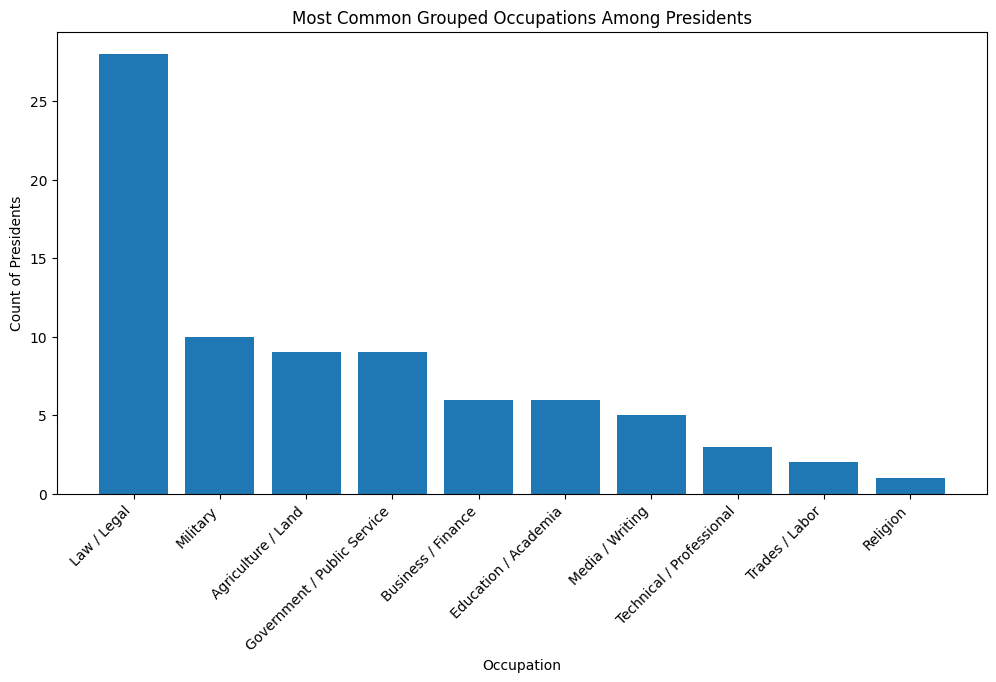

In [ ]:
occ_counts = occ_long["occupation_group"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(occ_counts.head(20).index, occ_counts.head(20).values)
plt.title("Most Common Grouped Occupations Among Presidents")
plt.xlabel("Occupation")
plt.ylabel("Count of Presidents")
plt.xticks(rotation=45, ha="right")
plt.show()

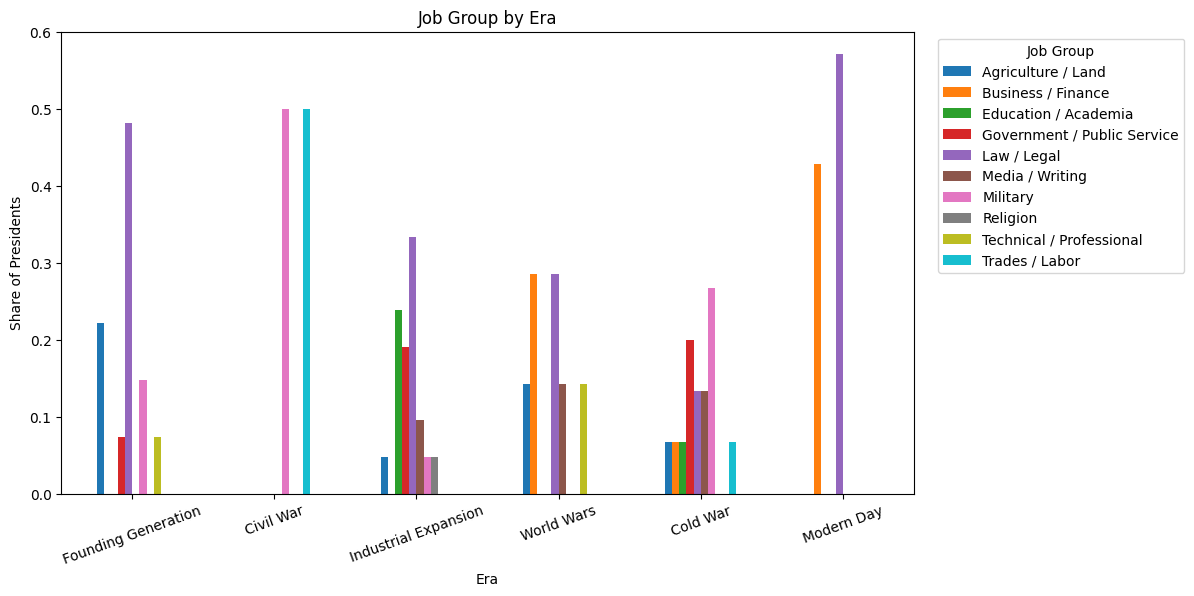

In [ ]:
job_by_era = pd.crosstab(occ_long["era"], occ_long["occupation_group"])
job_by_era_pct = job_by_era.div(job_by_era.sum(axis=1), axis=0)

job_by_era_pct.plot(kind="bar", figsize=(11, 6))
plt.title("Job Group by Era")
plt.xlabel("Era")
plt.ylabel("Share of Presidents")
plt.xticks(rotation=20)
plt.legend(title="Job Group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

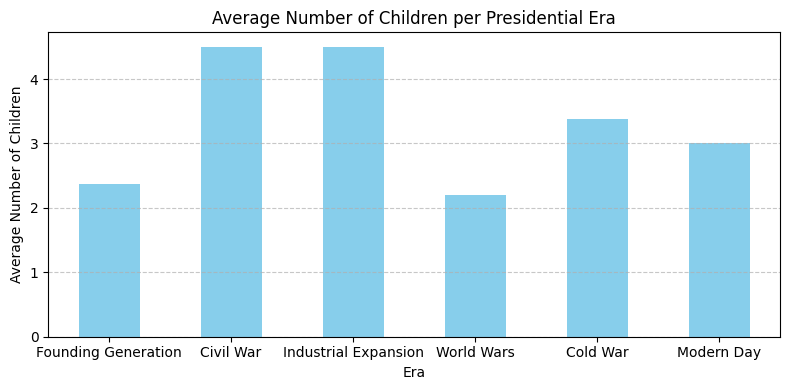

In [ ]:
# average number of children in each era
average_children_by_era = df.groupby('era', observed=True)['Children'].mean()

plt.figure(figsize=(8, 4))
average_children_by_era.plot(kind='bar', color='skyblue')
plt.title('Average Number of Children per Presidential Era')
plt.xlabel('Era')
plt.ylabel('Average Number of Children')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

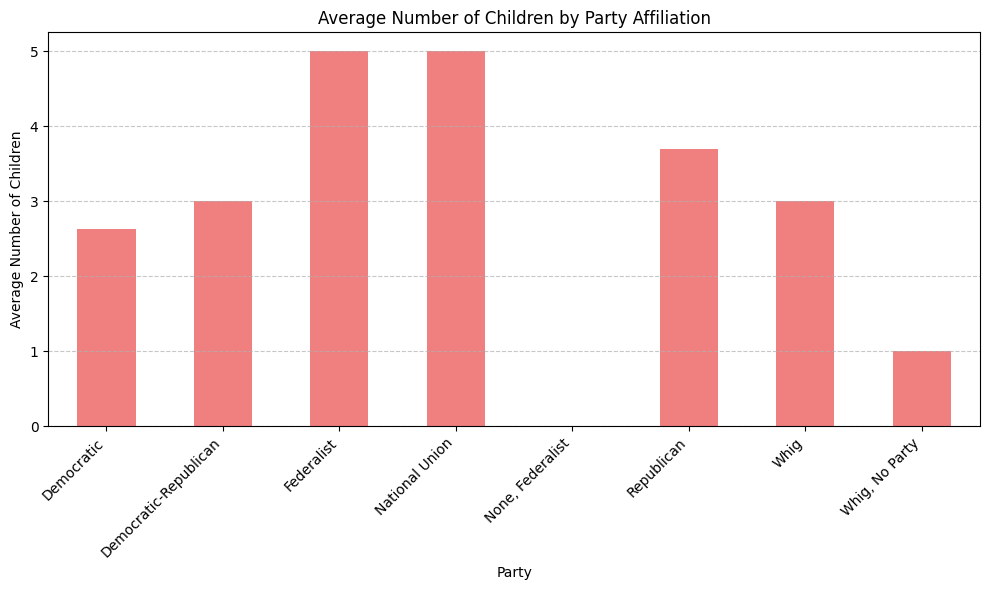

In [ ]:
# number of children vs. party affiliation EDA
plt.figure(figsize=(10, 6))
df.groupby('Party', observed=True)['Children'].mean().plot(kind='bar', color='lightcoral')
plt.title('Average Number of Children by Party Affiliation')
plt.xlabel('Party')
plt.ylabel('Average Number of Children')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

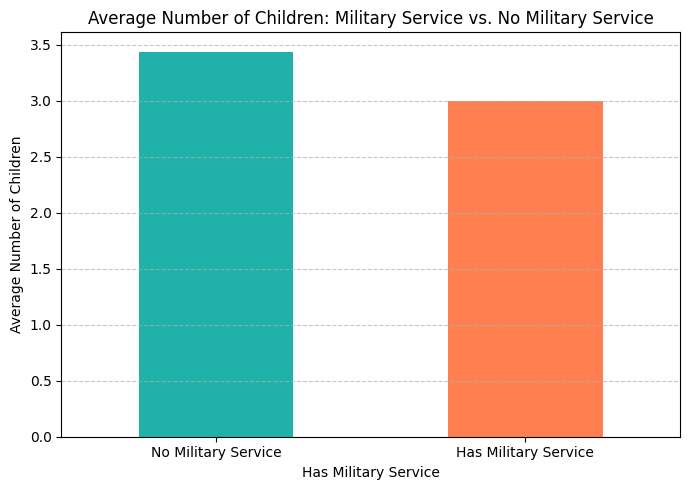

In [ ]:
avg_children_by_military = df.groupby('has_military_service')['Children'].mean()

plt.figure(figsize=(7, 5))
avg_children_by_military.plot(kind='bar', color=['lightseagreen', 'coral'])
plt.title('Average Number of Children: Military Service vs. No Military Service')
plt.xlabel('Has Military Service')
plt.ylabel('Average Number of Children')
plt.xticks(ticks=[0, 1], labels=['No Military Service', 'Has Military Service'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Era	                  Education Level	  Military Level	  Foreign Languages Spoke	  Age	  Number of Children
# Founding Generation
# Civil War
# Industrial Expansion
# World Wars
# Cold War
# Modern Day

In [ ]:
ed_df

,President,University,Highest Degree Held
0,George Washington,NaN,NaN
1,John Adams,Harvard University,Master of Arts
2,Thomas Jefferson,The College of William & Mary,Bachelors
3,James Madison,Princeton University,Bachelors
4,James Monroe,The College of William & Mary,NaN
5,John Quincy Adams,Harvard University,Masters
6,Andrew Jackson,NaN,NaN
7,Martin Van Buren,NaN,NaN
8,William Henry Harrison,University of Pennsylvania,NaN
9,John Tyler,The College of William & Mary,Bachelors


In [ ]:
ed_df = pd.read_csv("Meghan Data - College + Degree.csv")

In [ ]:
# 0 - no degree
# 1 - bachelors
# 2 - masters
# 3 - j.d., phd

In [ ]:
lang_df = pd.read_csv("Meghan Data - Languages Spoken (Other than English).csv")

In [ ]:
lang_df # for presidents not listed, include 1. add 1 to the rest to account for english

,Name,Unnamed: 1,Fluent,Partial,Num. Languages Fluency,Num. Languages Partial,Latin,Greek,French,German,Spanish,Dutch,Hebrew,Indonesian,Mandarin Chinese,Russian,Old English,Italian
0,John Adams,2.0,"Latin, French",NaN,2.0,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Thomas Jefferson,4.5,"Latin, French, Italian","Greek, Spanish, Old English",3.0,3.0,1.0,0.5,1.0,NaN,0.5,NaN,NaN,NaN,NaN,NaN,0.5,1.0
2,James Madison,3.0,"Latin, Greek, Hebrew",NaN,3.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
3,James Monroe,1.0,French,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,John Quincy Adams,5.5,"Latin, French, German","Greek, Spanish, Dutch, Russian, Italian",3.0,5.0,1.0,0.5,1.0,1.0,0.5,0.5,NaN,NaN,NaN,0.5,NaN,0.5
5,Martin Van Buren,1.5,Dutch,Latin,1.0,1.0,0.5,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
6,William Henry Harrison,1.5,Latin,French,1.0,1.0,1.0,NaN,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,John Tyler,2.0,"Latin, Greek",NaN,2.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,James K. Polk,2.0,"Latin, Greek",NaN,2.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,James Buchanan,2.0,"Latin, Greek",NaN,2.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# age and number of children

In [ ]:
import pandas as pd
import numpy as np

# Make a copy so you don't accidentally overwrite the original
ed_clean = ed_df.copy()

# Clean degree text
ed_clean["degree_clean"] = (
    ed_clean["Highest Degree Held"]
    .fillna("No degree")
    .str.lower()
    .str.strip()
)

# Map degree text to your 0–3 scale
def education_score(degree):
    if pd.isna(degree):
        return 0

    degree = str(degree).lower().strip()

    if degree in ["nan", "none", "no degree"]:
        return 0

    if "bachelor" in degree:
        return 1

    if "master" in degree:
        return 2

    if (
        "j.d" in degree
        or "jd" in degree
        or "juris doctor" in degree
        or "phd" in degree
        or "ph.d" in degree
        or "doctor" in degree
    ):
        return 3

    return np.nan  # helpful for catching weird/unmatched values

ed_clean["Education Level"] = ed_clean["Highest Degree Held"].apply(education_score)

ed_clean

,President,University,Highest Degree Held,degree_clean,Education Level
0,George Washington,NaN,NaN,no degree,0
1,John Adams,Harvard University,Master of Arts,master of arts,2
2,Thomas Jefferson,The College of William & Mary,Bachelors,bachelors,1
3,James Madison,Princeton University,Bachelors,bachelors,1
4,James Monroe,The College of William & Mary,NaN,no degree,0
5,John Quincy Adams,Harvard University,Masters,masters,2
6,Andrew Jackson,NaN,NaN,no degree,0
7,Martin Van Buren,NaN,NaN,no degree,0
8,William Henry Harrison,University of Pennsylvania,NaN,no degree,0
9,John Tyler,The College of William & Mary,Bachelors,bachelors,1


In [ ]:
# Keep only the columns you need from the main presidential df
military_cols = df[
    [
        "Name",
        "era",
        "military_level",
        "military_level_num"
    ]
].copy()

# Merge military info into your education table
pres_profile_df = ed_clean.merge(
    military_cols,
    left_on="President",
    right_on="Name",
    how="left"
)

# Optional: drop duplicate name column after merge
pres_profile_df = pres_profile_df.drop(columns=["Name"])

pres_profile_df.head()

,President,University,Highest Degree Held,degree_clean,Education Level,era,military_level,military_level_num
0,George Washington,NaN,NaN,no degree,0,Founding Generation,Top command,4
1,John Adams,Harvard University,Master of Arts,master of arts,2,Founding Generation,No service,0
2,Thomas Jefferson,The College of William & Mary,Bachelors,bachelors,1,Founding Generation,Mid-level officer,2
3,James Madison,Princeton University,Bachelors,bachelors,1,Founding Generation,Mid-level officer,2
4,James Monroe,The College of William & Mary,NaN,no degree,0,Founding Generation,Mid-level officer,2


In [ ]:
lang_clean = lang_df.copy()

# Rename for easier merging
lang_clean = lang_clean.rename(columns={
    "Name": "President",
    "Num. Languages Fluency": "Additional Fluent Languages",
    "Num. Languages Partial": "Additional Partial Languages"
})

# Keep the columns you need
lang_cols = lang_clean[
    [
        "President",
        "Fluent",
        "Partial",
        "Additional Fluent Languages",
        "Additional Partial Languages"
    ]
].copy()

# Merge into your full president profile table
pres_profile_df = pres_profile_df.merge(
    lang_cols,
    on="President",
    how="left"
)

# Missing = no documented additional languages
pres_profile_df["Additional Fluent Languages"] = pres_profile_df["Additional Fluent Languages"].fillna(0)
pres_profile_df["Additional Partial Languages"] = pres_profile_df["Additional Partial Languages"].fillna(0)

# Add English to everyone
pres_profile_df["Languages Spoken Num"] = (
    1
    + pres_profile_df["Additional Fluent Languages"]
    + pres_profile_df["Additional Partial Languages"]
)

# Optional: text labels for display
pres_profile_df["Languages Spoken"] = np.where(
    pres_profile_df["Fluent"].notna() | pres_profile_df["Partial"].notna(),
    "English + "
    + pres_profile_df["Fluent"].fillna("")
    + np.where(
        pres_profile_df["Partial"].notna(),
        " + partial: " + pres_profile_df["Partial"].fillna(""),
        ""
    ),
    "English only"
)

pres_profile_df.head()

,President,University,Highest Degree Held,degree_clean,Education Level,era,military_level,military_level_num,Fluent,Partial,Additional Fluent Languages,Additional Partial Languages,Languages Spoken Num,Languages Spoken
0,George Washington,NaN,NaN,no degree,0,Founding Generation,Top command,4,NaN,NaN,0.0,0.0,1.0,English only
1,John Adams,Harvard University,Master of Arts,master of arts,2,Founding Generation,No service,0,"Latin, French",NaN,2.0,0.0,3.0,"English + Latin, French"
2,Thomas Jefferson,The College of William & Mary,Bachelors,bachelors,1,Founding Generation,Mid-level officer,2,"Latin, French, Italian","Greek, Spanish, Old English",3.0,3.0,7.0,"English + Latin, French, Italian + partial: Greek, Spanish, Old English"
3,James Madison,Princeton University,Bachelors,bachelors,1,Founding Generation,Mid-level officer,2,"Latin, Greek, Hebrew",NaN,3.0,0.0,4.0,"English + Latin, Greek, Hebrew"
4,James Monroe,The College of William & Mary,NaN,no degree,0,Founding Generation,Mid-level officer,2,French,NaN,1.0,0.0,2.0,English + French


In [ ]:
gen_df = pd.read_csv("Meghan Data - General Info.csv")

In [ ]:
gen_df

,President,Number President,Birth State,Death State,University,Highest Degree Held,# Countries Visited as President,Age Taking Office,Height,Children,Religion,Occupation,Military Service,Term,Party,Vice President,Previous Office,has_higher_education,previous_office_group,term_start,term_end,era,has_military_service,military_level,military_level_num,# Executive Orders,Portrait,Summary
0,George Washington,1,Virginia,Virginia,No University,No Degree,NaN,57.18,1.88,2,Episcopalian,"Plantation Owner, Soldier",Commander-in-Chief of the Continental Army in the Revolutionary War,1789-1797,"None, Federalist",John Adams,Commander-in-Chief,False,Military Leadership,1789,1797,Founding Generation,True,Top command,4,8,https://tile.loc.gov/storage-services/service/pnp/cph/3a00000/3a09000/3a09900/3a09915v.jpg,"It was almost inevitable that George Washington, one of the most respected men in the colonies and the hero of the R..."
1,John Adams,2,Massachusetts,Massachusetts,Harvard University,Masters,NaN,61.34,1.70,6,Unitarian,"Lawyer, Farmer",none,1797-1801,Federalist,Thomas Jefferson,1st Vice President of USA,True,Vice President,1797,1801,Founding Generation,False,No service,0,1,https://tile.loc.gov/storage-services/service/pnp/cph/3a50000/3a53000/3a53200/3a53276r.jpg,"John Adams was one of the most fervent proponents in the colonies of independence from Britain, and used his eloquen..."
2,Thomas Jefferson,3,Virginia,Virginia,The College of William & Mary,Bachelors,NaN,57.89,1.89,14,unaffiliated Christian,"Inventor,Lawyer, Architect",Colonel of Virginia militia (without real military service),1801-1809,Democratic-Republican,"Aaron Burr, George Clinton",2nd Vice President of USA,True,Vice President,1801,1809,Founding Generation,True,Mid-level officer,2,4,https://tile.loc.gov/storage-services/service/pnp/ppmsca/15700/15708v.jpg,"Thomas Jefferson was truly a Renaissance man. A brilliant scholar, inventor, naturalist, and architect, Jefferson pl..."
3,James Madison,4,Virginia,Virginia,Princeton University,Bachelors,NaN,57.97,1.63,2,Episcopalian,"Plantation Owner, Lawyer",Colonel of Virginia militia (without real military service),1809-1817,Democratic-Republican,"George Clinton, Elbridge Gerry",Secretary of State,True,Cabinet,1809,1817,Founding Generation,True,Mid-level officer,2,1,https://tile.loc.gov/storage-services/service/pnp/ppmsca/19100/19166v.jpg,"Nicknamed ""The Father of the Constitution"" for his work on the document, James Madison was also a framer of the Bill..."
4,James Monroe,5,Virginia,New York,The College of William & Mary,No Degree,NaN,58.85,1.83,3,Episcopalian,"Plantation Owner, Lawyer",Major of the Continental Army,1817-1825,Democratic-Republican,Daniel Tompkins,Secretary of War,True,Cabinet,1817,1825,Civil War,True,Mid-level officer,2,1,https://tile.loc.gov/storage-services/service/pnp/cph/3c10000/3c17000/3c17100/3c17118v.jpg,"The last patriot of the Revolutionary era to become president, Monroe was elected at a time when the nation was at p..."
5,John Quincy Adams,6,Massachusetts,District of Columbia,Harvard University,Masters,NaN,57.65,1.70,5,Unitarian,"Lawyer, Diplomat",none,1825-1829,Democratic-Republican,John Calhoun,Secretary of State,True,Cabinet,1825,1829,Civil War,False,No service,0,3,https://tile.loc.gov/storage-services/service/pnp/cph/3c10000/3c17000/3c17100/3c17119v.jpg,"The son of John Adams, the illustrious patriot and second President of the United States, John Quincy Adams had been..."
6,Andrew Jackson,7,Tennessee,Tennessee,No University,No Degree,NaN,61.97,1.85,3,Presbyterian,"Soldier, Lawyer",Major General of U.S. Army,1829-1837,Democratic,"John Calhoun, Martin van Buren",Military Governor of Florida,False,Governor,1829,1837,Civil War,True,Senior leadership,3,12,https://tile.loc.gov/storage-services/service/pnp/cph/3c10000/3c17000/3c17100/3c17120v.jpg,"The first president to be born in a log cabin (although hardly the last to claim to be!), Andrew Jackson was also th..."
7,Martin Van Buren,8,New York,New York,

In [ ]:
gen_cols = gen_df[
    [
        "President",
        "Age Taking Office",
        "Children"
    ]
].copy()

pres_profile_df = pres_profile_df.merge(
    gen_cols,
    on="President",
    how="left"
)

pres_profile_df

,President,University,Highest Degree Held,degree_clean,Education Level,era,military_level,military_level_num,Fluent,Partial,Additional Fluent Languages,Additional Partial Languages,Languages Spoken Num,Languages Spoken,Age Taking Office_x,Children_x,Age Taking Office_y,Children_y
0,George Washington,NaN,NaN,no degree,0,Founding Generation,Top command,4,NaN,NaN,0.0,0.0,1.0,English only,57.18,2,57.18,2
1,John Adams,Harvard University,Master of Arts,master of arts,2,Founding Generation,No service,0,"Latin, French",NaN,2.0,0.0,3.0,"English + Latin, French",61.34,6,61.34,6
2,Thomas Jefferson,The College of William & Mary,Bachelors,bachelors,1,Founding Generation,Mid-level officer,2,"Latin, French, Italian","Greek, Spanish, Old English",3.0,3.0,7.0,"English + Latin, French, Italian + partial: Greek, Spanish, Old English",57.89,14,57.89,14
3,James Madison,Princeton University,Bachelors,bachelors,1,Founding Generation,Mid-level officer,2,"Latin, Greek, Hebrew",NaN,3.0,0.0,4.0,"English + Latin, Greek, Hebrew",57.97,2,57.97,2
4,James Monroe,The College of William & Mary,NaN,no degree,0,Founding Generation,Mid-level officer,2,French,NaN,1.0,0.0,2.0,English + French,58.85,3,58.85,3
5,John Quincy Adams,Harvard University,Masters,masters,2,Founding Generation,No service,0,"Latin, French, German","Greek, Spanish, Dutch, Russian, Italian",3.0,5.0,9.0,"English + Latin, French, German + partial: Greek, Spanish, Dutch, Russian, Italian",57.65,5,57.65,5
6,Andrew Jackson,NaN,NaN,no degree,0,Founding Generation,Senior leadership,3,NaN,NaN,0.0,0.0,1.0,English only,61.97,3,61.97,3
7,Martin Van Buren,NaN,NaN,no degree,0,Founding Generation,NaN,NaN,Dutch,Latin,1.0,1.0,3.0,English + Dutch + partial: Latin,54.24,6,54.24,6
8,William Henry Harrison,University of Pennsylvania,NaN,no degree,0,Founding Generation,NaN,NaN,Latin,French,1.0,1.0,3.0,English + Latin + partial: French,68.06,16,68.06,16
9,John Tyler,The College of William & Mary,Bachelors,bachelors,1,Founding Generation,Lower-level service,1,"Latin, Greek",NaN,2.0,0.0,3.0,"English + Latin, Greek",51.02,16,51.02,16


In [ ]:
era_map = {
    # Founding Generation
    "George Washington": "Founding Generation",
    "John Adams": "Founding Generation",
    "Thomas Jefferson": "Founding Generation",
    "James Madison": "Founding Generation",
    "James Monroe": "Founding Generation",
    "John Quincy Adams": "Founding Generation",
    "Andrew Jackson": "Founding Generation",
    "Martin Van Buren": "Founding Generation",
    "William Henry Harrison": "Founding Generation",
    "John Tyler": "Founding Generation",
    "James K. Polk": "Founding Generation",
    "Zachary Taylor": "Founding Generation",
    "Millard Fillmore": "Founding Generation",
    "Franklin Pierce": "Founding Generation",
    "James Buchanan": "Founding Generation",

    # Civil War / Reconstruction
    "Abraham Lincoln": "Civil War",
    "Andrew Johnson": "Civil War",
    "Ulysses S. Grant": "Civil War",

    # Industrial Expansion
    "Rutherford B. Hayes": "Industrial Expansion",
    "James A. Garfield": "Industrial Expansion",
    "Chester A. Arthur": "Industrial Expansion",
    "Grover Cleveland": "Industrial Expansion",
    "Benjamin Harrison": "Industrial Expansion",
    "William McKinley": "Industrial Expansion",
    "Theodore Roosevelt": "Industrial Expansion",
    "William Howard Taft": "Industrial Expansion",

    # World Wars
    "Woodrow Wilson": "World Wars",
    "Warren G. Harding": "World Wars",
    "Calvin Coolidge": "World Wars",
    "Herbert Hoover": "World Wars",
    "Franklin D. Roosevelt": "World Wars",

    # Cold War
    "Harry S. Truman": "Cold War",
    "Dwight D. Eisenhower": "Cold War",
    "John F. Kennedy": "Cold War",
    "Lyndon B. Johnson": "Cold War",
    "Richard Nixon": "Cold War",
    "Gerald Ford": "Cold War",
    "Jimmy Carter": "Cold War",
    "Ronald Reagan": "Cold War",
    "George H. W. Bush": "Cold War",

    # Modern Day
    "Bill Clinton": "Modern Day",
    "George W. Bush": "Modern Day",
    "Barack Obama": "Modern Day",
    "Donald Trump": "Modern Day",
    "Joe Biden": "Modern Day",
}

# Update the Era column
pres_profile_df["era"] = pres_profile_df["President"].map(era_map)

# Check for presidents who did not match
pres_profile_df[pres_profile_df["era"].isna()][["President", "era"]]

,President,era


In [ ]:
pres_profile_df = pres_profile_df.drop_duplicates(
    subset=["President"],
    keep="first"
).reset_index(drop=True)

pres_profile_df

,President,University,Highest Degree Held,degree_clean,Education Level,era,military_level,military_level_num,Fluent,Partial,Additional Fluent Languages,Additional Partial Languages,Languages Spoken Num,Languages Spoken,Age Taking Office,Children
0,George Washington,NaN,NaN,no degree,0,Founding Generation,Top command,4,NaN,NaN,0.0,0.0,1.0,English only,57.18,2
1,John Adams,Harvard University,Master of Arts,master of arts,2,Founding Generation,No service,0,"Latin, French",NaN,2.0,0.0,3.0,"English + Latin, French",61.34,6
2,Thomas Jefferson,The College of William & Mary,Bachelors,bachelors,1,Founding Generation,Mid-level officer,2,"Latin, French, Italian","Greek, Spanish, Old English",3.0,3.0,7.0,"English + Latin, French, Italian + partial: Greek, Spanish, Old English",57.89,14
3,James Madison,Princeton University,Bachelors,bachelors,1,Founding Generation,Mid-level officer,2,"Latin, Greek, Hebrew",NaN,3.0,0.0,4.0,"English + Latin, Greek, Hebrew",57.97,2
4,James Monroe,The College of William & Mary,NaN,no degree,0,Founding Generation,Mid-level officer,2,French,NaN,1.0,0.0,2.0,English + French,58.85,3
5,John Quincy Adams,Harvard University,Masters,masters,2,Founding Generation,No service,0,"Latin, French, German","Greek, Spanish, Dutch, Russian, Italian",3.0,5.0,9.0,"English + Latin, French, German + partial: Greek, Spanish, Dutch, Russian, Italian",57.65,5
6,Andrew Jackson,NaN,NaN,no degree,0,Founding Generation,Senior leadership,3,NaN,NaN,0.0,0.0,1.0,English only,61.97,3
7,Martin Van Buren,NaN,NaN,no degree,0,Founding Generation,NaN,NaN,Dutch,Latin,1.0,1.0,3.0,English + Dutch + partial: Latin,54.24,6
8,William Henry Harrison,University of Pennsylvania,NaN,no degree,0,Founding Generation,NaN,NaN,Latin,French,1.0,1.0,3.0,English + Latin + partial: French,68.06,16
9,John Tyler,The College of William & Mary,Bachelors,bachelors,1,Founding Generation,Lower-level service,1,"Latin, Greek",NaN,2.0,0.0,3.0,"English + Latin, Greek",51.02,16


In [ ]:
radar_base_df = pres_profile_df[
    [
        "President",
        "era",
        "Education Level",
        "military_level_num",
        "Languages Spoken Num",
        "Age Taking Office",
        "Children"
    ]
].copy()

radar_base_df = radar_base_df.rename(columns={
    "Military Level Num": "Military Level",
    "Languages Spoken Num": "Foreign Languages Spoke",
    "Age Taking Office": "Age",
    "Children": "Number of Children"
})

radar_base_df

,President,era,Education Level,military_level_num,Foreign Languages Spoke,Age,Number of Children
0,George Washington,Founding Generation,0,4,1.0,57.18,2
1,John Adams,Founding Generation,2,0,3.0,61.34,6
2,Thomas Jefferson,Founding Generation,1,2,7.0,57.89,14
3,James Madison,Founding Generation,1,2,4.0,57.97,2
4,James Monroe,Founding Generation,0,2,2.0,58.85,3
5,John Quincy Adams,Founding Generation,2,0,9.0,57.65,5
6,Andrew Jackson,Founding Generation,0,3,1.0,61.97,3
7,Martin Van Buren,Founding Generation,0,NaN,3.0,54.24,6
8,William Henry Harrison,Founding Generation,0,NaN,3.0,68.06,16
9,John Tyler,Founding Generation,1,1,3.0,51.02,16


In [ ]:
df[["Name", "Military Service"]]

,Name,Military Service
0,George Washington,Commander-in-Chief of the Continental Army in the Revolutionary War
1,John Adams,none
2,Thomas Jefferson,Colonel of Virginia militia (without real military service)
3,James Madison,Colonel of Virginia militia (without real military service)
4,James Monroe,Major of the Continental Army
5,John Quincy Adams,none
6,Andrew Jackson,Major General of U.S. Army
7,Martin van Buren,none
8,William H. Harrison,Major General of U.S. Army
9,John Tyler,Captain of Virginia militia


In [ ]:
radar_base_df.to_csv("radar_base_messy.csv")

In [ ]:
radar_base_df = pd.read_csv("radar_base_clean.csv")

In [ ]:
radar_base_df

,Unnamed: 0,President,era,Education Level,military_level_num,Foreign Languages Spoke,Age,Number of Children
0,0,George Washington,Founding Generation,0,4,1.0,57.18,2
1,1,John Adams,Founding Generation,2,0,3.0,61.34,6
2,2,Thomas Jefferson,Founding Generation,1,2,7.0,57.89,14
3,3,James Madison,Founding Generation,1,2,4.0,57.97,2
4,4,James Monroe,Founding Generation,0,2,2.0,58.85,3
5,5,John Quincy Adams,Founding Generation,2,0,9.0,57.65,5
6,6,Andrew Jackson,Founding Generation,0,3,1.0,61.97,3
7,7,Martin Van Buren,Founding Generation,0,0,3.0,54.24,6
8,8,William Henry Harrison,Founding Generation,0,3,3.0,68.06,16
9,9,John Tyler,Founding Generation,1,1,3.0,51.02,16


In [ ]:
# Start from the president-level table, not the era-average table
radar_norm_pres_df = radar_base_df.copy()

cols_to_normalize = [
    "Education Level",
    "military_level_num",
    "Foreign Languages Spoke",
    "Age",
    "Number of Children"
]

# Make sure values are numeric
radar_norm_pres_df[cols_to_normalize] = radar_norm_pres_df[cols_to_normalize].apply(
    pd.to_numeric,
    errors="coerce"
)

# Normalize president-level values to 0–5
for col in cols_to_normalize:
    min_val = radar_norm_pres_df[col].min()
    max_val = radar_norm_pres_df[col].max()

    if max_val == min_val:
        radar_norm_pres_df[col] = 0
    else:
        radar_norm_pres_df[col] = (
            5 * (radar_norm_pres_df[col] - min_val) / (max_val - min_val)
        )

# Now average the normalized values by era
era_radar_norm_df = (
    radar_norm_pres_df
    .groupby("era", as_index=False)[cols_to_normalize]
    .mean()
    .round(2)
)


era_radar_norm_df = (
    era_radar_norm_df
    .sort_values("era")
    .reset_index(drop=True)
)

era_radar_norm_df

,era,Education Level,military_level_num,Foreign Languages Spoke,Age,Number of Children
0,Civil War,0.56,3.33,0.00,1.25,1.35
1,Cold War,1.85,2.22,0.07,2.05,1.04
2,Founding Generation,1.11,2.33,1.25,2.06,1.79
3,Industrial Expansion,1.25,2.34,1.09,1.37,1.52
4,Modern Day,4.00,0.25,0.38,2.35,0.88
5,World Wars,2.33,0.00,0.75,2.09,0.94


In [ ]:
radar_norm_pres_df.to_csv("radar_pres.csv")

In [ ]:
era_avg_df = (
    radar_base_df
    .groupby("era", as_index=False)[cols_to_normalize]
    .mean()
    .round(2)
)

In [ ]:
era_avg_df

,era,Education Level,military_level_num,Foreign Languages Spoke,Age,Number of Children
0,Civil War,0.33,2.67,1.00,51.73,4.33
1,Cold War,1.11,1.78,1.11,57.33,3.33
2,Founding Generation,0.67,1.87,3.00,57.43,5.73
3,Industrial Expansion,0.75,1.88,2.75,52.52,4.88
4,Modern Day,2.40,0.20,1.60,59.44,2.80
5,World Wars,1.40,0.00,2.20,57.65,3.00


In [ ]:
era_avg_df.to_csv('era_averages.csv')

In [ ]:
era_radar_norm_df.to_csv('era_norm.csv')